In [1]:
%%writefile my_mlp.cpp

#include <stdint.h>
#include <stdlib.h>
#include <math.h>

#if defined(_WIN32) || defined(__WIN32__)
#define DLLEXPORT __declspec(dllexport)
#else
#define DLLEXPORT
#endif

// un réseau de neurones multicouche
struct MLP {
    int32_t* npl;         // Tableau contenant le nombre de neurones par couche (ex: [2, 3, 1])
    int32_t num_layers;   // Nombre total de couches
    double*** W;          // Poids : W[l][i][j] (couche l, neurone i de provenance, neurone j d'arrivée)
    double** X;           // Signal de sortie / Activations : X[l][j]
    double** deltas;      // Erreurs de rétropropagation : deltas[l][j]
};

// fonction d'activation Tanh
double tanh_custom(double x) {
    return tanh(x);
}

// dérivée de Tanh ==> f'(x) = 1 - tanh^2(x)
double tanh_derivative(double x) {
    return 1.0 - (x * x);
}

extern "C" {

// 1. CRÉATION DU MODÈLE MLP
DLLEXPORT MLP* create_mlp_model(const int32_t* npl, int32_t npl_length) {
    MLP* model = new MLP();
    model->num_layers = npl_length;

    // Copie de la structure des couches
    model->npl = new int32_t[npl_length];
    for (int l = 0; l < npl_length; ++l) {
        model->npl[l] = npl[l];
    }

    // Allocation des activations X et des deltas
    model->X = new double*[npl_length];
    model->deltas = new double*[npl_length];

    for (int l = 0; l < npl_length; ++l) {
        // +1 pour le terme de Biais à l'index 0 (sauf sur la dernière couche)
        int size = npl[l] + (l < npl_length - 1 ? 1 : 0);
        model->X[l] = new double[size];
        model->deltas[l] = new double[size]();

        // Initialisation du biais à 1.0
        if (l < npl_length - 1) {
            model->X[l][0] = 1.0;
        }
    }

    // Allocation et initialisation aléatoire des poids W [-1, 1]
    model->W = new double**[npl_length];
    for (int l = 1; l < npl_length; ++l) {
        int prev_neurons = npl[l - 1] + 1; // +1 pour le biais
        int curr_neurons = npl[l] + 1;     // +1 pour le biais de la couche suivante

        model->W[l] = new double*[prev_neurons];
        for (int i = 0; i < prev_neurons; ++i) {
            model->W[l][i] = new double[curr_neurons];
            for (int j = 0; j < curr_neurons; ++j) {
                // Initialisation aléatoire entre -1.0 et 1.0
                model->W[l][i][j] = ((double)rand() / RAND_MAX) * 2.0 - 1.0;
            }
        }
    }

    return model;
}

// 2. FORWARD PASS (Propagations avant)
DLLEXPORT void forward_pass(MLP* model, const double* raw_sample, bool is_classification) {
    // Remplir la couche d'entrée (l = 0)
    for (int j = 1; j <= model->npl[0]; ++j) {
        model->X[0][j] = raw_sample[j - 1];
    }

    // Propagation à travers les couches cachées et de sortie
    for (int l = 1; l < model->num_layers; ++l) {
        for (int j = 1; j <= model->npl[l]; ++j) {
            double sum = 0.0;
            for (int i = 0; i <= model->npl[l - 1]; ++i) { // i = 0 est le biais
                sum += model->W[l][i][j] * model->X[l - 1][i];
            }

            // Si c'est la dernière couche et qu'on fait de la régression pure, pas de Tanh
            if (l == model->num_layers - 1 && !is_classification) {
                model->X[l][j] = sum;
            } else {
                model->X[l][j] = tanh_custom(sum);
            }
        }
    }
}

// PREDICT (Expose le Forward Pass vers Python)
DLLEXPORT double* predict_mlp_model(MLP* model, const double* raw_sample, bool is_classification) {
    forward_pass(model, raw_sample, is_classification);

    // Retourne le pointeur vers les sorties de la dernière couche
    int last_layer = model->num_layers - 1;
    return &model->X[last_layer][1];
}

// 3. BACKPROPAGATION (Entraînement / Rétropropagation de l'erreur)
DLLEXPORT void train_mlp_model(MLP* model, const double* raw_X, const double* raw_Y,
                            int32_t num_samples, int32_t num_features, int32_t target_dim,
                            double alpha, int32_t epochs, bool is_classification) {
    int L = model->num_layers - 1;

    for (int epoch = 0; epoch < epochs; ++epoch) {
        for (int k = 0; k < num_samples; ++k) {
            // Sélection de l'échantillon courant
            const double* sample_X = &raw_X[k * num_features];
            const double* sample_Y = &raw_Y[k * target_dim];

            // 1. Forward pass
            forward_pass(model, sample_X, is_classification);

            // 2. Calcul des deltas sur la couche de SORTIE (l = L)
            for (int j = 1; j <= model->npl[L]; ++j) {
                double y_pred = model->X[L][j];
                double target = sample_Y[j - 1];
                double error = y_pred - target;

                if (!is_classification) {
                    model->deltas[L][j] = error;
                } else {
                    model->deltas[L][j] = error * tanh_derivative(y_pred);
                }
            }

            // 3. Rétropropagation des deltas (couches L-1 vers 1)
            for (int l = L; l >= 2; --l) {
                for (int i = 0; i <= model->npl[l - 1]; ++i) {
                    double sum = 0.0;
                    for (int j = 1; j <= model->npl[l]; ++j) {
                        sum += model->W[l][i][j] * model->deltas[l][j];
                    }
                    model->deltas[l - 1][i] = sum * tanh_derivative(model->X[l - 1][i]);
                }
            }

            // 4. Mise à jour des poids W (Gradient Descent)
            for (int l = 1; l <= L; ++l) {
                for (int i = 0; i <= model->npl[l - 1]; ++i) {
                    for (int j = 1; j <= model->npl[l]; ++j) {
                        model->W[l][i][j] -= alpha * model->X[l - 1][i] * model->deltas[l][j];
                    }
                }
            }
        }
    }
}

// 4. DESTRUCTION DU MODÈLE (Nettoyage de la mémoire)
DLLEXPORT void destroy_mlp_model(MLP* model) {
    if (!model) return;

    for (int l = 0; l < model->num_layers; ++l) {
        delete[] model->X[l];
        delete[] model->deltas[l];

        if (l > 0) {
            int prev_neurons = model->npl[l - 1] + 1;
            for (int i = 0; i < prev_neurons; ++i) {
                delete[] model->W[l][i];
            }
            delete[] model->W[l];
        }
    }

    delete[] model->X;
    delete[] model->deltas;
    delete[] model->W;
    delete[] model->npl;
    delete model;
}
// Fonction pour calculer la perte (Loss / MSE) à un instant T
DLLEXPORT double get_mlp_loss(MLP* model, const double* raw_X, const double* raw_Y,
                             int32_t num_samples, int32_t num_features, int32_t target_dim,
                             bool is_classification) {
    double total_loss = 0.0;
    int L = model->num_layers - 1;

    for (int k = 0; k < num_samples; ++k) {
        const double* sample_X = &raw_X[k * num_features];
        const double* sample_Y = &raw_Y[k * target_dim];

        forward_pass(model, sample_X, is_classification);

        for (int j = 1; j <= model->npl[L]; ++j) {
            double diff = model->X[L][j] - sample_Y[j - 1];
            total_loss += diff * diff;
        }
    }
    return total_loss / (num_samples * target_dim);
}
} // extern "C"


Writing my_mlp.cpp


In [2]:
import ctypes
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Compilation C++ sous Linux (Kaggle)
!g++ -O3 -shared -fPIC -o libPA.so my_mlp.cpp

# 2. Chargement de la bibliothèque .so
cpp_lib = ctypes.CDLL(os.path.abspath("./libPA.so"))

# Bindings Ctypes (Signatures des fonctions C++)
cpp_lib.create_mlp_model.argtypes = [ctypes.POINTER(ctypes.c_int32), ctypes.c_int32]
cpp_lib.create_mlp_model.restype = ctypes.c_void_p

cpp_lib.predict_mlp_model.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_double), ctypes.c_bool]
cpp_lib.predict_mlp_model.restype = ctypes.POINTER(ctypes.c_double)

cpp_lib.train_mlp_model.argtypes = [
    ctypes.c_void_p, ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.c_int32, ctypes.c_int32, ctypes.c_int32, ctypes.c_double, ctypes.c_int32, ctypes.c_bool
]
cpp_lib.train_mlp_model.restype = None

cpp_lib.get_mlp_loss.argtypes = [
    ctypes.c_void_p, ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.c_int32, ctypes.c_int32, ctypes.c_int32, ctypes.c_bool
]
cpp_lib.get_mlp_loss.restype = ctypes.c_double

cpp_lib.destroy_mlp_model.argtypes = [ctypes.c_void_p]
cpp_lib.destroy_mlp_model.restype = None


# Fonction simple de calcul des métriques et d'affichage
def plot_results(title, X, Y, model, npl, losses, total_epochs, step):
    output_dim = npl[-1]
    
    # 1. Calcul des prédictions sur le dataset pour l'Accuracy
    y_preds = []
    for row in X:
        row_c = np.ascontiguousarray(row, dtype=np.float64)
        ptr = row_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
        pred_ptr = cpp_lib.predict_mlp_model(model, ptr, True)
        
        if output_dim == 1:
            y_preds.append(1 if pred_ptr[0] >= 0 else -1)
        else:
            y_preds.append(np.argmax([pred_ptr[i] for i in range(output_dim)]))
    
    # Vraies classes
    y_true = Y.flatten() if output_dim == 1 else np.argmax(Y, axis=1)
    
    # Calcul manuel de l'Accuracy
    accuracy = np.mean(np.array(y_preds) == y_true) * 100
    print(f"=== {title} ===")
    print(f"Accuracy : {accuracy:.2f}%")
    if losses:
        print(f"Loss finale (MSE) : {losses[-1]:.6f}")

    # 2. Graphiques : Loss à gauche, Surface de décision à droite
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Graphique de la Perte (MSE)
    if losses:
        ax1.plot(range(0, total_epochs, step), losses, color='purple', linewidth=2)
        ax1.set_title(f"{title} - Loss (MSE)")
        ax1.set_xlabel("Époques")
        ax1.set_ylabel("Erreur")
        ax1.grid(True)

    # Surface de Décision
    margin = 0.2
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-margin, X[:,0].max()+margin, 100),
                         np.linspace(X[:,1].min()-margin, X[:,1].max()+margin, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = []
    for pt in grid:
        pt_c = np.ascontiguousarray(pt, dtype=np.float64)
        ptr = pt_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
        pred_ptr = cpp_lib.predict_mlp_model(model, ptr, True)
        Z.append(pred_ptr[0] if output_dim == 1 else np.argmax([pred_ptr[i] for i in range(output_dim)]))

    Z = np.array(Z).reshape(xx.shape)
    ax2.set_title(f"{title} (Acc: {accuracy:.1f}%)")

    if output_dim == 1:
        ax2.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.7)
        ax2.scatter(X[y_true == 1, 0], X[y_true == 1, 1], color='blue', edgecolors='k', label='Classe +1')
        ax2.scatter(X[y_true == -1, 0], X[y_true == -1, 1], color='red', edgecolors='k', label='Classe -1')
    else:
        ax2.contourf(xx, yy, Z, levels=np.arange(-0.5, output_dim, 1), cmap='Set1', alpha=0.5)
        colors = ['blue', 'red', 'green', 'orange']
        for c in range(output_dim):
            ax2.scatter(X[y_true == c, 0], X[y_true == c, 1], color=colors[c % len(colors)], edgecolors='k', label=f'Classe {c}')

    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

# Test 1 - Linear Simple
## MLP [2, 1]

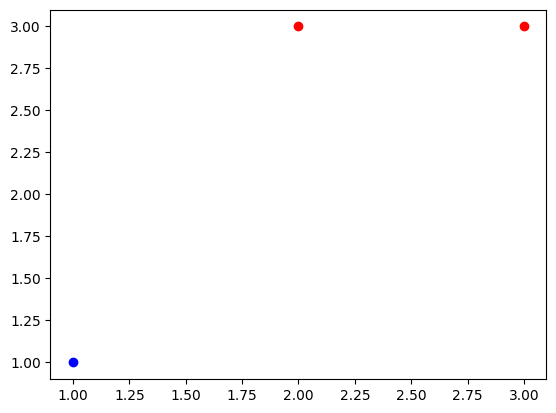

<Figure size 640x480 with 0 Axes>

In [5]:
X = np.array([
    [1.0, 1.0],
    [2.0, 3.0],
    [3.0, 3.0]
], dtype=np.float64)

Y = np.array([
    [1.0],
    [-1.0],
    [-1.0]
], dtype=np.float64)

plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

=== Linear Simple ===
Accuracy : 100.00%
Loss finale (MSE) : 0.000884


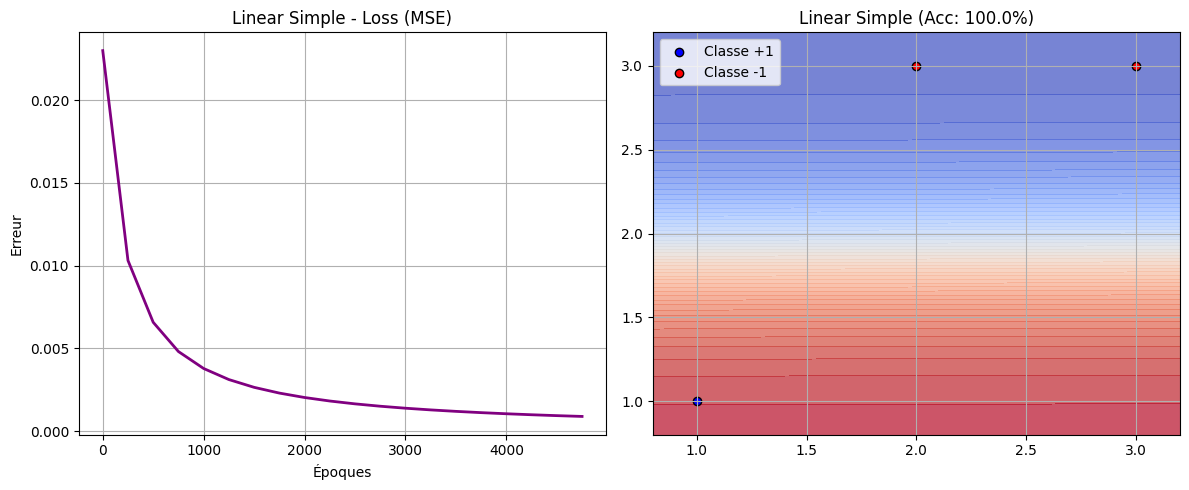

In [7]:
npl = [2, 1]
npl_array = np.array(npl, dtype=np.int32)
model = cpp_lib.create_mlp_model(npl_array.ctypes.data_as(ctypes.POINTER(ctypes.c_int32)), len(npl_array))

X_c = np.ascontiguousarray(X, dtype=np.float64)
Y_c = np.ascontiguousarray(Y, dtype=np.float64)

X_ptr = X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
Y_ptr = Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

# 3. Entraînement
losses = []
epochs, step = 5000, 250

for epoch in range(0, epochs, step):
    cpp_lib.train_mlp_model(model, X_ptr, Y_ptr, len(X_c), 2, 1, 0.05, step, True)
    losses.append(cpp_lib.get_mlp_loss(model, X_ptr, Y_ptr, len(X_c), 2, 1, True))

# 4. Affichage & Nettoyage
plot_results("Linear Simple", X_c, Y_c, model, npl, losses, epochs, step)
cpp_lib.destroy_mlp_model(model)

# Test 2 - Linear Multiple

=== Linear Multiple ===
Accuracy : 100.00%
Loss finale (MSE) : 0.000047


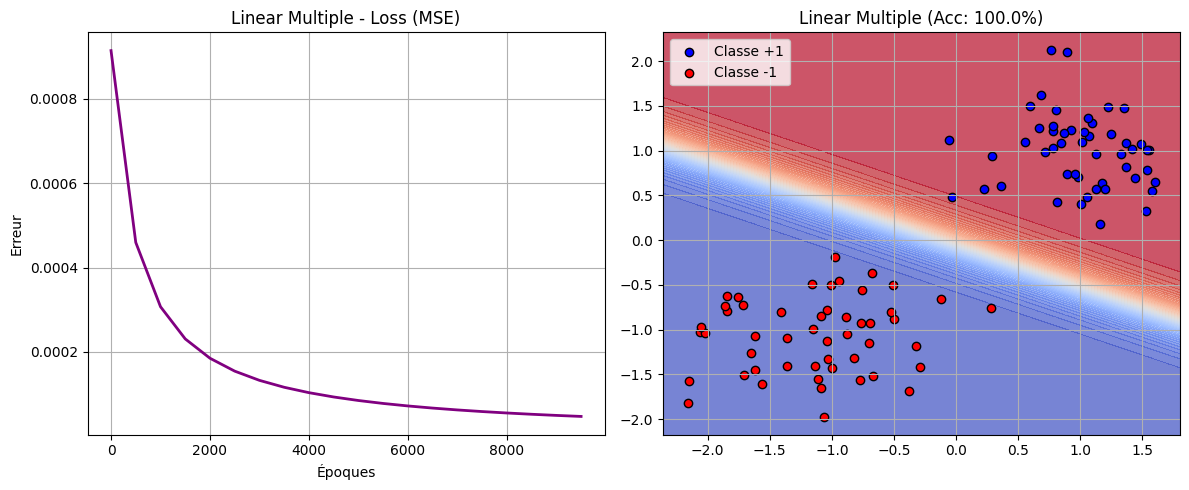

In [7]:
# 1. Données
X = np.concatenate([
    np.random.randn(50, 2) * 0.5 + np.array([1, 1]),
    np.random.randn(50, 2) * 0.5 + np.array([-1, -1])
], axis=0)

Y = np.concatenate([
    np.ones((50, 1)),
    -np.ones((50, 1))
], axis=0)

# 2. Modèle MLP [2, 1]
npl = [2, 1]
npl_array = np.array(npl, dtype=np.int32)
model = cpp_lib.create_mlp_model(npl_array.ctypes.data_as(ctypes.POINTER(ctypes.c_int32)), len(npl_array))

X_c = np.ascontiguousarray(X, dtype=np.float64)
Y_c = np.ascontiguousarray(Y, dtype=np.float64)

X_ptr = X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
Y_ptr = Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

# 3. Entraînement
losses = []
epochs, step = 10000, 500

for epoch in range(0, epochs, step):
    cpp_lib.train_mlp_model(model, X_ptr, Y_ptr, len(X_c), 2, 1, 0.01, step, True)
    losses.append(cpp_lib.get_mlp_loss(model, X_ptr, Y_ptr, len(X_c), 2, 1, True))

# 4. Affichage & Nettoyage
plot_results("Linear Multiple", X_c, Y_c, model, npl, losses, epochs, step)
cpp_lib.destroy_mlp_model(model)

# Test 3 - XOR

=== XOR ===
Accuracy : 100.00%
Loss finale (MSE) : 0.000067


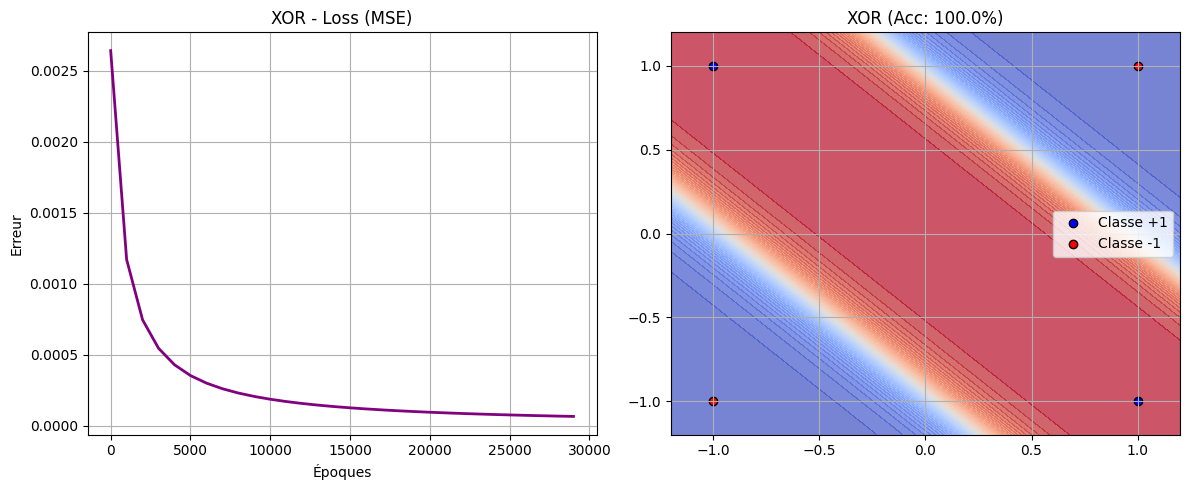

In [8]:
# 1. Données
X = np.array([
    [1.0, 1.0],
    [-1.0, 1.0],
    [-1.0, -1.0],
    [1.0, -1.0]
], dtype=np.float64)

Y = np.array([
    [-1.0],
    [1.0],
    [-1.0],
    [1.0]
], dtype=np.float64)

# 2. Modèle MLP [2, 2, 1] (Couche cachée indispensable)
npl = [2, 2, 1]
npl_array = np.array(npl, dtype=np.int32)
model = cpp_lib.create_mlp_model(npl_array.ctypes.data_as(ctypes.POINTER(ctypes.c_int32)), len(npl_array))

X_c = np.ascontiguousarray(X, dtype=np.float64)
Y_c = np.ascontiguousarray(Y, dtype=np.float64)

X_ptr = X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
Y_ptr = Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

# 3. Entraînement
losses = []
epochs, step = 30000, 1000

for epoch in range(0, epochs, step):
    cpp_lib.train_mlp_model(model, X_ptr, Y_ptr, len(X_c), 2, 1, 0.05, step, True)
    losses.append(cpp_lib.get_mlp_loss(model, X_ptr, Y_ptr, len(X_c), 2, 1, True))

# 4. Affichage & Nettoyage
plot_results("XOR", X_c, Y_c, model, npl, losses, epochs, step)
cpp_lib.destroy_mlp_model(model)

# Test 4 - Cross

=== Cross ===
Accuracy : 99.40%
Loss finale (MSE) : 0.031823


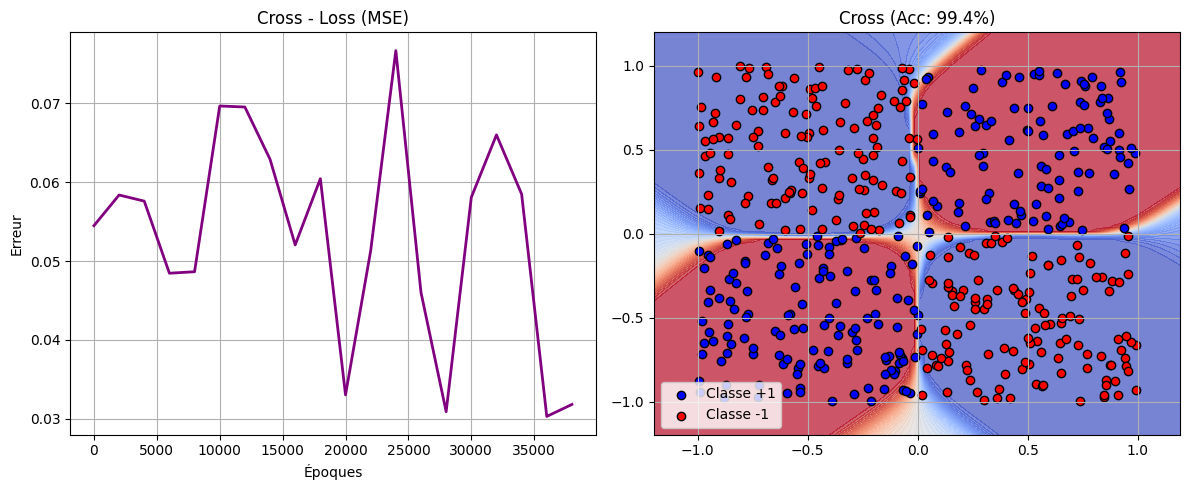

In [9]:
# 1. Données
X = np.random.uniform(-1, 1, (500, 2))
Y = np.array([
    [1.0] if (pt[0] * pt[1] > 0) else [-1.0]
    for pt in X
], dtype=np.float64)

# 2. Modèle MLP [2, 4, 1]
npl = [2, 4, 1]
npl_array = np.array(npl, dtype=np.int32)
model = cpp_lib.create_mlp_model(npl_array.ctypes.data_as(ctypes.POINTER(ctypes.c_int32)), len(npl_array))

X_c = np.ascontiguousarray(X, dtype=np.float64)
Y_c = np.ascontiguousarray(Y, dtype=np.float64)

X_ptr = X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
Y_ptr = Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

# 3. Entraînement
losses = []
epochs, step = 40000, 2000

for epoch in range(0, epochs, step):
    cpp_lib.train_mlp_model(model, X_ptr, Y_ptr, len(X_c), 2, 1, 0.01, step, True)
    losses.append(cpp_lib.get_mlp_loss(model, X_ptr, Y_ptr, len(X_c), 2, 1, True))

# 4. Affichage & Nettoyage
plot_results("Cross", X_c, Y_c, model, npl, losses, epochs, step)
cpp_lib.destroy_mlp_model(model)

# Test 5 - Multi Linear (3 Classes)

In [ ]:
# 1. Données (3 Classes)
X = np.random.uniform(-1, 1, (500, 2))
Y = np.zeros((500, 3), dtype=np.float64)

for i, pt in enumerate(X):
    if pt[0] + pt[1] > 0.3:
        Y[i] = [1.0, -1.0, -1.0]
    elif pt[0] + pt[1] < -0.3:
        Y[i] = [-1.0, 1.0, -1.0]
    else:
        Y[i] = [-1.0, -1.0, 1.0]

# 2. Modèle MLP [2, 3] (3 neurones de sortie)
npl = [2, 3]
npl_array = np.array(npl, dtype=np.int32)
model = cpp_lib.create_mlp_model(npl_array.ctypes.data_as(ctypes.POINTER(ctypes.c_int32)), len(npl_array))

X_c = np.ascontiguousarray(X, dtype=np.float64)
Y_c = np.ascontiguousarray(Y, dtype=np.float64)

X_ptr = X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
Y_ptr = Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

# 3. Entraînement
losses = []
epochs, step = 20000, 1000

for epoch in range(0, epochs, step):
    cpp_lib.train_mlp_model(model, X_ptr, Y_ptr, len(X_c), 2, 3, 0.01, step, True)
    losses.append(cpp_lib.get_mlp_loss(model, X_ptr, Y_ptr, len(X_c), 2, 3, True))

# 4. Affichage & Nettoyage
plot_results("Multi-Linear", X_c, Y_c, model, npl, losses, epochs, step)
cpp_lib.destroy_mlp_model(model)

=== Multi-Linear ===
Accuracy : 98.60%
Loss finale (MSE) : 0.273510


# Test 6 - Multi Cross (3 Classes)

=== Multi-Cross ===
Accuracy : 90.00%
Loss finale (MSE) : 0.161515


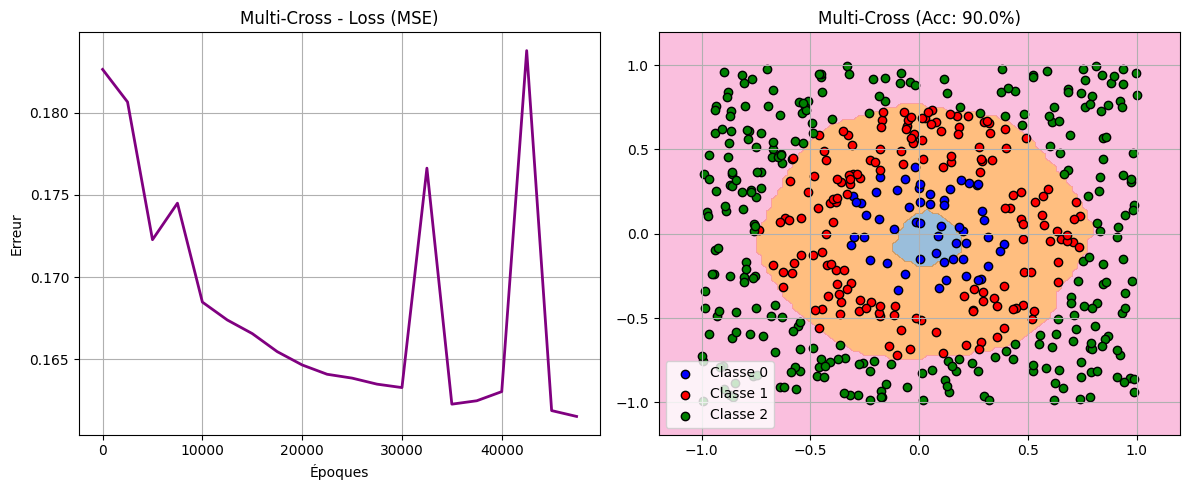

In [4]:
# 1. Données (3 Classes en cercles concentriques)
X = np.random.uniform(-1, 1, (500, 2))
Y = np.zeros((500, 3), dtype=np.float64)

for i, pt in enumerate(X):
    r = np.sqrt(pt[0]**2 + pt[1]**2)
    if r < 0.4:
        Y[i] = [1.0, -1.0, -1.0]
    elif r < 0.75:
        Y[i] = [-1.0, 1.0, -1.0]
    else:
        Y[i] = [-1.0, -1.0, 1.0]

# 2. Modèle MLP [2, 8, 3]
npl = [2, 8, 3]
npl_array = np.array(npl, dtype=np.int32)
model = cpp_lib.create_mlp_model(npl_array.ctypes.data_as(ctypes.POINTER(ctypes.c_int32)), len(npl_array))

X_c = np.ascontiguousarray(X, dtype=np.float64)
Y_c = np.ascontiguousarray(Y, dtype=np.float64)

X_ptr = X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
Y_ptr = Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double))

# 3. Entraînement
losses = []
epochs, step = 50000, 2500

for epoch in range(0, epochs, step):
    cpp_lib.train_mlp_model(model, X_ptr, Y_ptr, len(X_c), 2, 3, 0.01, step, True)
    losses.append(cpp_lib.get_mlp_loss(model, X_ptr, Y_ptr, len(X_c), 2, 3, True))

# 4. Affichage & Nettoyage
plot_results("Multi-Cross", X_c, Y_c, model, npl, losses, epochs, step)
cpp_lib.destroy_mlp_model(model)